1. What is the average monthly revenue, expenses, and profit?

In [1]:

import pandas as pd


df = pd.read_csv("Datasets_50_Days_Of_Data_Analysis/financial_data.csv")
df.head()

,Date,Revenue,Expenses,Profit
0,31 01 2022,19000,5000,14000
1,28 02 2022,16000,5500,10500
2,31 03 2022,10000,7000,3000
3,30 04 2022,18000,8000,10000
4,31 05 2022,25000,9000,16000


In [2]:
avg_revenue = df['Revenue'].mean()
avg_expenses = df['Expenses'].mean()
avg_profit = df['Profit'].mean()

print(f"Average monthly revenue: {avg_revenue:.2f}")
print(f"Average monthly expenses: {avg_expenses:.2f}")
print(f"Average monthly profit: {avg_profit:.2f}")

Average monthly revenue: 35200.00
Average monthly expenses: 15425.00
Average monthly profit: 19775.00



2. How does the profit margin vary over time? Plot a line plot of the changes in profit margin.

In [4]:
df['Profit Margin'] = (df['Profit'] / df['Revenue']) * 100
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

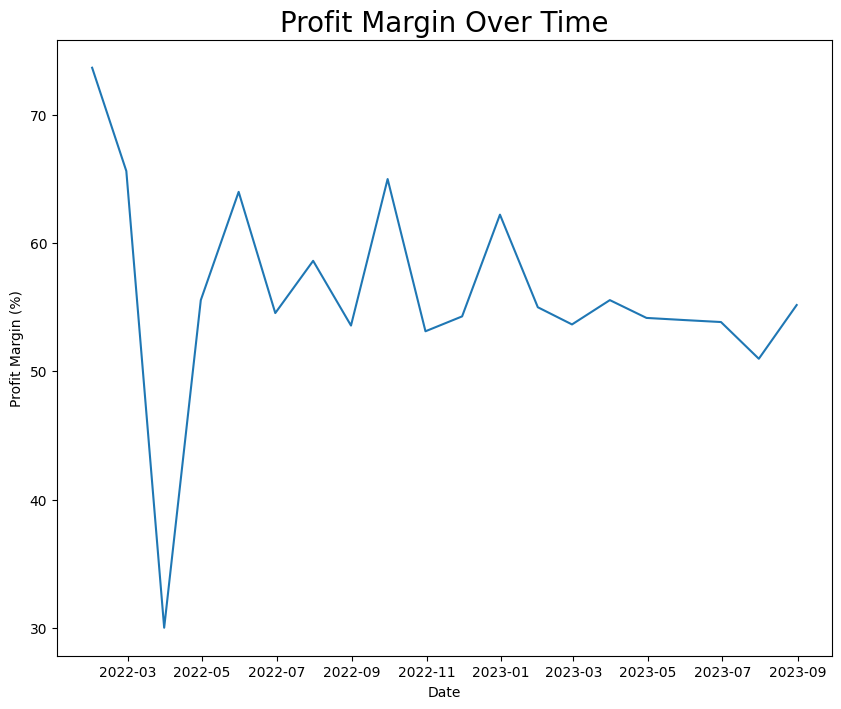

In [7]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.plot(df["Date"], df['Profit Margin'])
plt.xlabel('Date')
plt.ylabel('Profit Margin (%)')
plt.title('Profit Margin Over Time', fontsize = 20)
plt.show()


3. What is the difference between the revenue of the highest month and and that of the lowest months? Which month has the highest revenue and which month has the lowest revenue?

In [8]:
highest_revenue = df.loc[df['Revenue'] == df['Revenue'].max(), 'Revenue'].values[0]
lowest_revenue = df.loc[df['Revenue'] == df['Revenue'].min(), 'Revenue'].values[0]

difference = highest_revenue - lowest_revenue
print(f'The difference in Revenue is {difference}')

The difference in Revenue is 48000


In [9]:
df["Month"] = df["Date"].dt.month_name()

highest_month = df.loc[df['Revenue'] == df['Revenue'].max(), 'Month'].values[0]
lowest_month = df.loc[df['Revenue'] == df['Revenue'].min(), 'Month'].values[0]
print( f'The month with highest revenue is: {highest_month}')
print(f'The month with highest revenue is: {lowest_month}')

The month with highest revenue is: August
The month with highest revenue is: March



4. Which months had expenses above $10,000?

In [10]:
month_expenses_above_10 = df.loc[df['Expenses'] > 10000, 'Month']
month_expenses_above_10

6          July
7        August
8     September
9       October
10     November
11     December
12      January
13     February
14        March
15        April
16          May
17         June
18         July
19       August
Name: Month, dtype: object


5. How much profit was made in the last quarter of 2022?

In [11]:
df2 = df.groupby(df["Date"].dt.to_period('Q'))["Revenue"].sum()
df2

Date
2022Q1     45000
2022Q2     65000
2022Q3     97000
2022Q4    112000
2023Q1    126000
2023Q2    150000
2023Q3    109000
Freq: Q-DEC, Name: Revenue, dtype: int64

In [12]:

print(f'Revenue in the last quarter of 2022 is {df2.loc["2022Q4"]}')


Revenue in the last quarter of 2022 is 112000


6. What was the percentage change in revenue from quarter to quarter?

In [13]:

quarterly_revenue_change = df2.pct_change()

print("Percentage change in revenue from quarter to quarter:")
print(f'{quarterly_revenue_change:}')

Percentage change in revenue from quarter to quarter:
Date
2022Q1         NaN
2022Q2    0.444444
2022Q3    0.492308
2022Q4    0.154639
2023Q1    0.125000
2023Q2    0.190476
2023Q3   -0.273333
Freq: Q-DEC, Name: Revenue, dtype: float64
